In [1]:
# Main analysis: gradual and near-record changes in wearable sleep and circadian
# metrics in the days before a persistent postsurgical pain clinical record.
import os
import pandas as pd
import numpy as np
from helper_functions import *
from google.cloud import bigquery
import matplotlib.pyplot as plt

directory = 'notebooks/data'

In [2]:
# The Workspace Bucket path and BigQuery dataset are read from a local file that
# is not included in this repository. Expected format, one entry per line:
#     bucket = ~/workspace/rw-migration-...
#     BQ_dataset = wb-...-....C....
config_path = os.path.expanduser('KimWhibley_config.txt')

config = {}
with open(config_path) as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        key, value = line.split('=', 1)
        config[key.strip()] = value.strip()

bucket = config['bucket']
BQ_dataset = config['BQ_dataset']

In [3]:
job_query_config = bigquery.QueryJobConfig(
    default_dataset=BQ_dataset
)

client = bigquery.Client(
    default_query_job_config=job_query_config
)

In [4]:
combined_df = read_data_from_bucket("combined_df_main.csv",directory='notebooks/data', bucket = bucket)

In [5]:
# trim edges
combined_df = combined_df[
    (combined_df['days_before_onset'] >= 0) &
    (combined_df['days_before_onset'] <= 30)
]

## Table 1 — Linear mixed effects models (gradual change over days relative to the clinical record)

`metric ~ day + age + sex + (1 | participant)`, fit separately for bedtime, waketime, sleep duration, and HR phase. The cell below prints the result in the manuscript **Table 1** layout (`Estimate (SE)` / `p-value` per term, then marginal & conditional R² and `N groups (N observations)`).

In [6]:
import warnings
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.tools.sm_exceptions import ConvergenceWarning

SEX_FEMALE_TERM = 'C(sex_at_birth_source_value)[T.SexAtBirth_Female]'
SEX_MALE_TERM   = 'C(sex_at_birth_source_value)[T.SexAtBirth_Male]'


def analyze_metric_continuous(combined_df, target_variable, ylabel,
                              subject_col='person_id', day_col='days_rel_onset'):
    """Gradual model: metric ~ day + age + sex + (1 | person), REML.

    `day_col` is days relative to the clinical record (0 on the record day,
    negative before it). Returns (result, fit_df) so the R^2 helper can be
    evaluated on exactly the rows that were fit.
    """
    df = combined_df.copy()
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df[[target_variable, day_col, subject_col, "age", "sex_at_birth_source_value"]].dropna().copy()

    formula = f"{target_variable} ~ {day_col} + age + C(sex_at_birth_source_value)"
    result = smf.mixedlm(formula, data=df, groups=df[subject_col]).fit(reml=True)
    return result, df


def nakagawa_r2(result, df):
    """Marginal / conditional R^2 following Nakagawa & Schielzeth (2013)."""
    fe_only = result.predict(exog=df)
    var_fixed = float(np.var(fe_only))
    var_random = float(result.cov_re.iloc[0, 0])
    var_resid = float(result.scale)
    total_var = var_fixed + var_random + var_resid
    return var_fixed / total_var, (var_fixed + var_random) / total_var


def _fmt_est(b, se):
    return f"{b:.3f} ({se:.3f})"


def _fmt_p(p):
    return "<.001" if p < .001 else f"{p:.3f}"


def manuscript_lme_table(columns, time_term, time_label, include_intercept):
    """Assemble a manuscript-style fixed-effects table.

      columns          : list of (display_name, result, fit_df)
      time_term        : name of the day / near-record fixed effect
      time_label       : row label to show for that effect
      include_intercept: show the Intercept row (Table 1: yes, Table 2: no)

    Model terms are rendered as `Estimate (SE)` / `p-value` column pairs, with
    marginal & conditional R^2 and `N groups (N observations)` in the footer.
    """
    term_rows = []
    if include_intercept:
        term_rows.append(("Intercept", "Intercept"))
    term_rows += [
        ("Sex at birth (Female)", SEX_FEMALE_TERM),
        ("Sex at birth (Male)",   SEX_MALE_TERM),
        (time_label,              time_term),
        ("Age",                   "age"),
    ]

    data = {}
    for name, res, fit_df in columns:
        est, pv = {}, {}
        for label, term in term_rows:
            if term in res.fe_params.index:
                est[label] = _fmt_est(res.fe_params[term], res.bse[term])
                pv[label]  = _fmt_p(res.pvalues[term])
            else:
                est[label] = pv[label] = ""
        r2m, r2c = nakagawa_r2(res, fit_df)
        est["Marginal R²"]       = f"{r2m:.3f}"
        est["Conditional R²"]    = f"{r2c:.3f}"
        est["N (#observations)"]      = f"{int(len(res.random_effects))} ({int(res.nobs)})"
        pv["Marginal R²"] = pv["Conditional R²"] = pv["N (#observations)"] = ""
        data[(name, "Estimate (SE)")] = est
        data[(name, "p-value")]       = pv

    row_order = [r[0] for r in term_rows] + ["Marginal R²", "Conditional R²", "N (#observations)"]
    tbl = pd.DataFrame(data).reindex(row_order)
    tbl.columns = pd.MultiIndex.from_tuples(tbl.columns)
    return tbl


# ---- Fit the four gradual (days-relative-to-record) models ------------------
waketime_result, waketime_fitdf = analyze_metric_continuous(
    combined_df, target_variable='waketime_hours', ylabel='Waketime (hours)')

btdf = combined_df.copy()
btdf['bedtime_hours'] = btdf['bedtime_hours'].apply(lambda x: x + 24 if x < 12 else x)
bedtime_result, bedtime_fitdf = analyze_metric_continuous(
    btdf, target_variable='bedtime_hours', ylabel='Bedtime (hours)')

duration_result, duration_fitdf = analyze_metric_continuous(
    combined_df, target_variable='duration_hours', ylabel='Sleep duration (hours)')

hrdf = combined_df.copy()
hrdf['mean_hr_phase_hours'] = hrdf['mean_hr_phase_hours'].apply(lambda x: x + 24 if x < 12 else x)
hr_result, hr_fitdf = analyze_metric_continuous(
    hrdf, target_variable='mean_hr_phase_hours', ylabel='HR phase (hours)')

# ---- Table 1 : gradual associations with days relative to the clinical record
table1 = manuscript_lme_table(
    [("Bedtime",        bedtime_result,  bedtime_fitdf),
     ("Waketime",       waketime_result, waketime_fitdf),
     ("Sleep Duration", duration_result, duration_fitdf),
     ("HR phase",       hr_result,       hr_fitdf)],
    time_term="days_rel_onset",
    time_label="Days relative to record",
    include_intercept=True,
)

print("Table 1. Associations between days relative to clinical records and each metric\n"
      "(linear mixed effects models: metric ~ day + age + sex + (1 | participant); "
      "estimates are beta (SE)).\n")
print(table1.to_string())
table1

Table 1. Associations between days relative to clinical records and each metric
(linear mixed effects models: metric ~ day + age + sex + (1 | participant); estimates are beta (SE)).

                                Bedtime                Waketime          Sleep Duration                HR phase        
                          Estimate (SE) p-value   Estimate (SE) p-value   Estimate (SE) p-value   Estimate (SE) p-value
Intercept                24.014 (2.452)   <.001   8.735 (2.768)   0.002   9.129 (1.686)   <.001  26.445 (2.715)   <.001
Sex at birth (Female)    -0.418 (2.284)   0.855   0.118 (2.580)   0.963  -0.781 (1.568)   0.619  -0.877 (2.523)   0.728
Sex at birth (Male)      -1.515 (2.326)   0.515   0.060 (2.627)   0.982  -1.274 (1.597)   0.425  -0.848 (2.566)   0.741
Days relative to record  -0.005 (0.006)   0.401  -0.012 (0.006)   0.035  -0.006 (0.005)   0.149  -0.003 (0.010)   0.755
Age                      -0.002 (0.018)   0.918  -0.027 (0.020)   0.172  -0.025 (0.012)   0.039  

Bedtime                Waketime          \
                          Estimate (SE) p-value   Estimate (SE) p-value   
Intercept                24.014 (2.452)   <.001   8.735 (2.768)   0.002   
Sex at birth (Female)    -0.418 (2.284)   0.855   0.118 (2.580)   0.963   
Sex at birth (Male)      -1.515 (2.326)   0.515   0.060 (2.627)   0.982   
Days relative to record  -0.005 (0.006)   0.401  -0.012 (0.006)   0.035   
Age                      -0.002 (0.018)   0.918  -0.027 (0.020)   0.172   
Marginal R²                       0.019                   0.013           
Conditional R²                    0.495                   0.533           
N (#observations)             90 (2159)               90 (2159)           

                         Sleep Duration                HR phase          
                          Estimate (SE) p-value   Estimate (SE) p-value  
Intercept                 9.129 (1.686)   <.001  26.445 (2.715)   <.001  
Sex at birth (Female)    -0.781 (1.568)   0.619  -0.877 (2.523)   0.728  
Sex at birth (Male)      -1.274 (1.597)   0.425  -0.848 (2.566)   0.741  
Days relative to record  -0.006 (0.005)   0.149  -0.003 (0.010)   0.755  
Age                      -0.025 (0.012)   0.039   0.006 (0.020)   0.745  
Marginal R²                       0.033                   0.001          
Conditional R²                    0.428                   0.208          
N (#observations)             90 (2159)               92 (2671)

## Table 2 — Linear mixed effects models (short-term change in the near-record window, days 0–2)

`metric ~ near_record + age + sex + (1 | participant)`, where `near_record` marks days 0–2 before the clinical record. Fit for HR amplitude, HR mesor, bedtime, and waketime. The cell below prints the result in the manuscript **Table 2** layout and the accompanying trajectory plots.

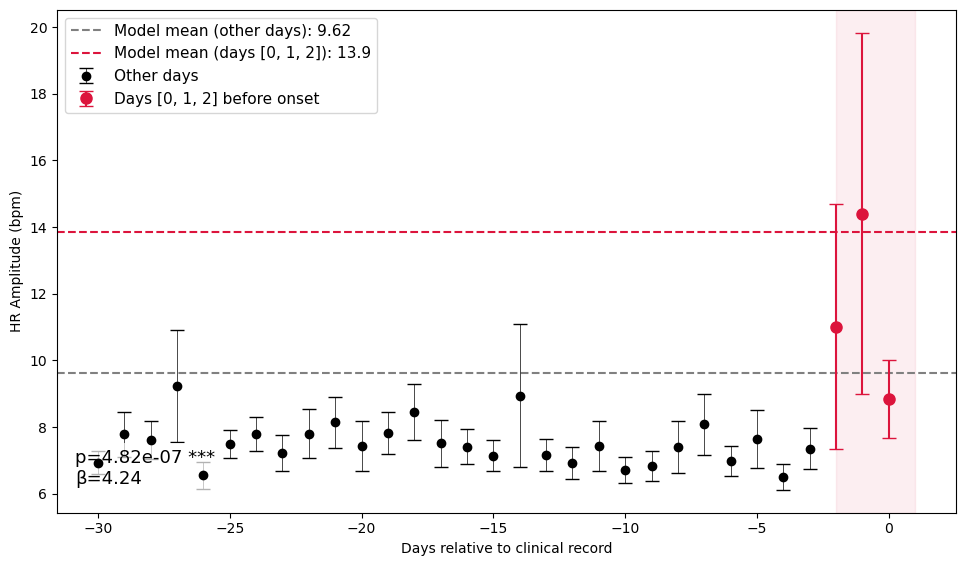

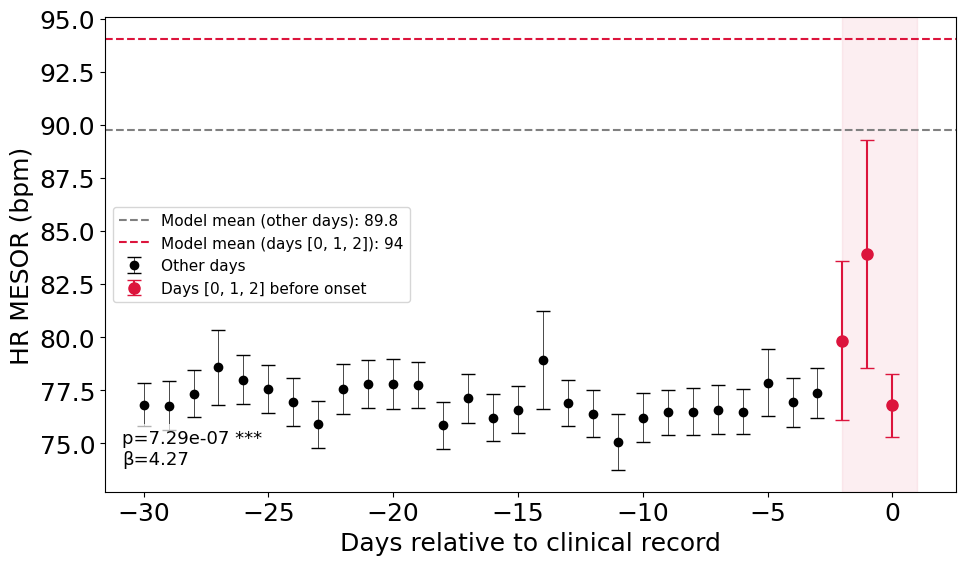

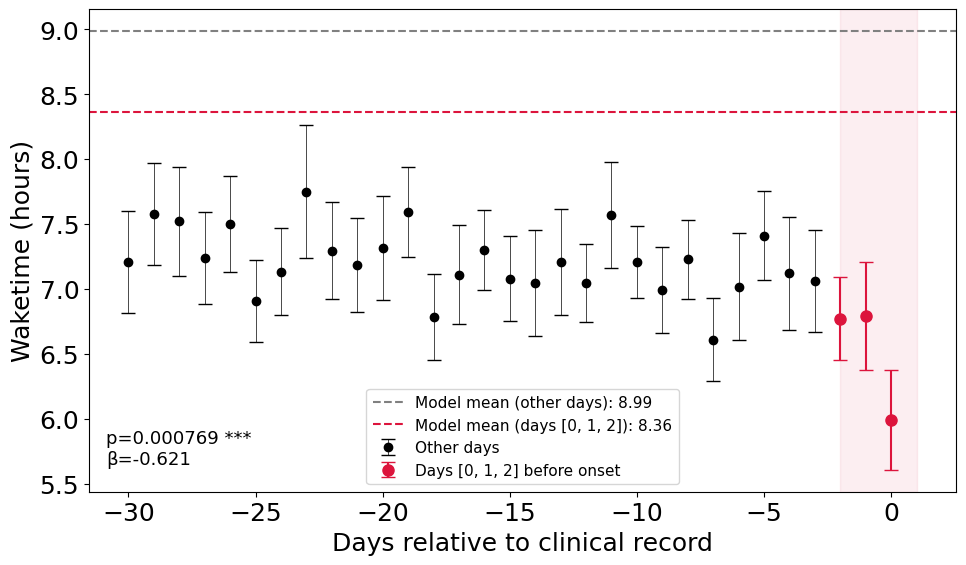

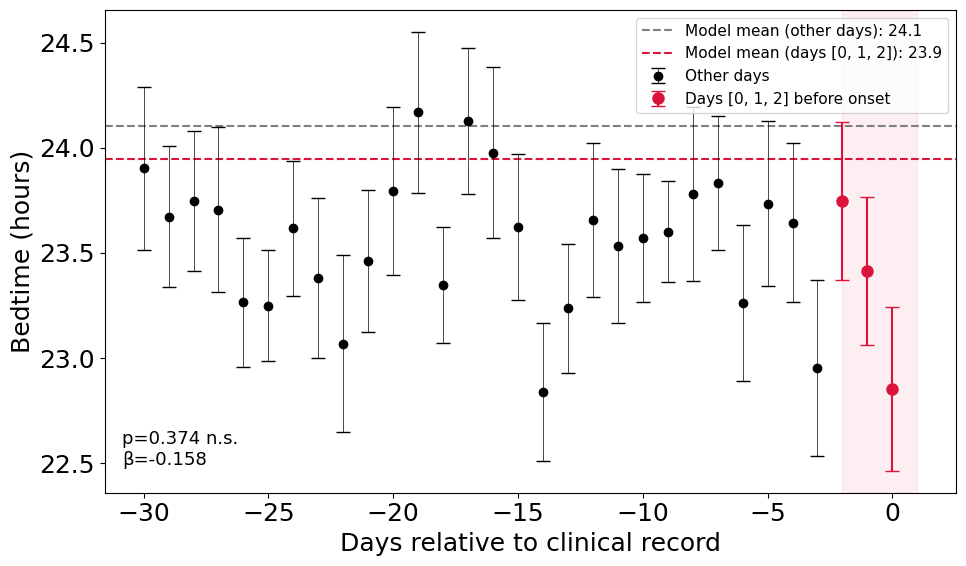

Table 2. Associations between the near-record window (days 0-2 before the clinical record) and each metric
(linear mixed effects models: metric ~ near_record + age + sex + (1 | participant); estimates are beta (SE)).

                          HR amplitude                HR mesor                 Bedtime                Waketime        
                         Estimate (SE) p-value   Estimate (SE) p-value   Estimate (SE) p-value   Estimate (SE) p-value
Sex at birth (Female)    2.502 (4.899)   0.610   5.318 (8.758)   0.544  -0.421 (2.284)   0.854   0.105 (2.587)   0.968
Sex at birth (Male)      1.196 (4.985)   0.810   0.680 (8.903)   0.939  -1.517 (2.325)   0.514   0.057 (2.634)   0.983
Near record (0-2 days)   4.236 (0.842)   <.001   4.274 (0.863)   <.001  -0.158 (0.177)   0.374  -0.621 (0.185)   <.001
Age                     -0.074 (0.039)   0.059  -0.289 (0.068)   <.001  -0.002 (0.018)   0.918  -0.027 (0.020)   0.175
Marginal R²                      0.017                   0.088      

HR amplitude                HR mesor          \
                         Estimate (SE) p-value   Estimate (SE) p-value   
Sex at birth (Female)    2.502 (4.899)   0.610   5.318 (8.758)   0.544   
Sex at birth (Male)      1.196 (4.985)   0.810   0.680 (8.903)   0.939   
Near record (0-2 days)   4.236 (0.842)   <.001   4.274 (0.863)   <.001   
Age                     -0.074 (0.039)   0.059  -0.289 (0.068)   <.001   
Marginal R²                      0.017                   0.088           
Conditional R²                   0.125                   0.369           
N (#observations)            92 (2671)               92 (2671)           

                               Bedtime                Waketime          
                         Estimate (SE) p-value   Estimate (SE) p-value  
Sex at birth (Female)   -0.421 (2.284)   0.854   0.105 (2.587)   0.968  
Sex at birth (Male)     -1.517 (2.325)   0.514   0.057 (2.634)   0.983  
Near record (0-2 days)  -0.158 (0.177)   0.374  -0.621 (0.185)   <.001  
Age                     -0.002 (0.018)   0.918  -0.027 (0.020)   0.175  
Marginal R²                      0.019                   0.014          
Conditional R²                   0.495                   0.536          
N (#observations)            90 (2159)               90 (2159)

In [7]:
def analyze_metric_categorical(combined_df, target_variable, ylabel,
                                subject_col='person_id', day_col='days_before_onset',
                                fit_window=30, near_onset_days=(0, 1, 2)):
    """
    Near-record model: metric ~ near_record + age + sex + (1 | person), REML,
    where `near_record` is 1 on days 0-2 before the clinical record and 0 on the
    rest of the fit window. Returns (result, plot_df, df_fit).
    """
    df = combined_df.copy()
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df[[target_variable, day_col, subject_col, "age", "sex_at_birth_source_value"]].dropna().copy()

    # Restrict to fit window
    df_fit = df[df[day_col] <= fit_window].copy()

    # Binary indicator: 1 if in the near-onset window, 0 otherwise
    df_fit['near_onset'] = df_fit[day_col].isin(near_onset_days).astype(int)

    formula = f"{target_variable} ~ near_onset + age + C(sex_at_birth_source_value)"
    result = smf.mixedlm(
        formula,
        data=df_fit,
        groups=df_fit[subject_col]
    ).fit(reml=True)

    coef = result.fe_params['near_onset']
    pval = result.pvalues['near_onset']

    # Plot
    plot_source = combined_df[[target_variable, day_col]].dropna().copy()
    plot_source['day_int'] = plot_source[day_col].astype(int)
    plot_source['near_onset'] = plot_source['day_int'].isin(near_onset_days)

    plot_df = (
        plot_source.groupby('day_int')[target_variable]
        .agg(mean='mean', se=lambda x: x.std() / np.sqrt(len(x)))
        .reset_index()
    )
    plot_df['x_plot'] = -plot_df['day_int']
    plot_df['near_onset'] = plot_df['day_int'].isin(near_onset_days)
    plot_df = plot_df.sort_values('day_int')

    # Split into near-onset and background points
    near = plot_df[plot_df['near_onset']]
    rest = plot_df[~plot_df['near_onset']]

    plt.figure(figsize=(10, 6))

    # Background days
    plt.errorbar(rest['x_plot'], rest['mean'], yerr=rest['se'],
                 fmt='o', capsize=5, color='k', linewidth=0.5,
                 markersize=6, zorder=3, label='Other days')

    # Near-onset days (highlighted)
    plt.errorbar(near['x_plot'], near['mean'], yerr=near['se'],
                 fmt='o', capsize=5, color='crimson', linewidth=1.5,
                 markersize=8, zorder=4,
                 label=f'Days {list(near_onset_days)} before onset')

    # Shade near-onset region
    plt.axvspan(-max(near_onset_days), -min(near_onset_days) + 1,
                color='crimson', alpha=0.07, zorder=0)

    # Predicted group means as horizontal lines over their respective regions
    intercept = result.fe_params['Intercept']
    y_rest   = intercept                 # near_onset == 0
    y_near   = intercept + coef          # near_onset == 1

    plt.axhline(y_rest, color='gray',    linestyle='--', linewidth=1.5,
                xmin=0, xmax=1, label=f'Model mean (other days): {y_rest:.3g}')
    plt.axhline(y_near, color='crimson', linestyle='--', linewidth=1.5,
                label=f'Model mean (days {list(near_onset_days)}): {y_near:.3g}')

    # Annotation
    signif  = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'n.s.'
    p_label = f"p={pval:.3g} {signif}\nβ={coef:.3g}"
    plt.text(0.02, 0.05, p_label, transform=plt.gca().transAxes,
             fontsize=13, verticalalignment='bottom',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    plt.xlabel('Days relative to clinical record')
    plt.ylabel(ylabel)
    plt.legend(fontsize=11)
    plt.rcParams.update({'font.size': 18})
    plt.tight_layout()
    plt.show()

    return result, plot_df, df_fit

# Linear metrics
amp_contrasts, amp_plot, amp_df = analyze_metric_categorical(
    combined_df, target_variable='mean_hr_amp', ylabel='HR Amplitude (bpm)',
    subject_col='person_id', day_col='days_before_onset',
    fit_window=30, near_onset_days=(0, 1, 2)
)

mesor_contrasts, mesor_plot, mesor_df = analyze_metric_categorical(
    combined_df, target_variable='mean_hr_mesor', ylabel='HR MESOR (bpm)',
    subject_col='person_id', day_col='days_before_onset',
    fit_window=30, near_onset_days=(0, 1, 2)
)

# Timing metrics
first_waketime_contrasts, first_waketime_plot, waketime_df = analyze_metric_categorical(
    combined_df,
    target_variable='waketime_hours',
    ylabel='Waketime (hours)',
    subject_col='person_id', day_col='days_before_onset',
    fit_window=30, near_onset_days=(0, 1, 2)
)

# for bedtime, address midnight value jump
btdf = combined_df.copy()
btdf['bedtime_hours'] = btdf['bedtime_hours'].apply(
    lambda x: x + 24 if x < 12 else x
)

bedtime_contrasts, bedtime_plot, bedtime_df = analyze_metric_categorical(
    btdf,
    target_variable='bedtime_hours',
    ylabel='Bedtime (hours)',
    subject_col='person_id', day_col='days_before_onset',
    fit_window=30, near_onset_days=(0, 1, 2)
)

# ---- Table 2 : associations with the near-record window (days 0-2) ----------
table2 = manuscript_lme_table(
    [("HR amplitude", amp_contrasts,            amp_df),
     ("HR mesor",     mesor_contrasts,          mesor_df),
     ("Bedtime",      bedtime_contrasts,        bedtime_df),
     ("Waketime",     first_waketime_contrasts, waketime_df)],
    time_term="near_onset",
    time_label="Near record (0-2 days)",
    include_intercept=False,
)

print("Table 2. Associations between the near-record window (days 0-2 before the "
      "clinical record) and each metric\n(linear mixed effects models: "
      "metric ~ near_record + age + sex + (1 | participant); estimates are beta (SE)).\n")
print(table2.to_string())
table2

## Plots of metric trajectories

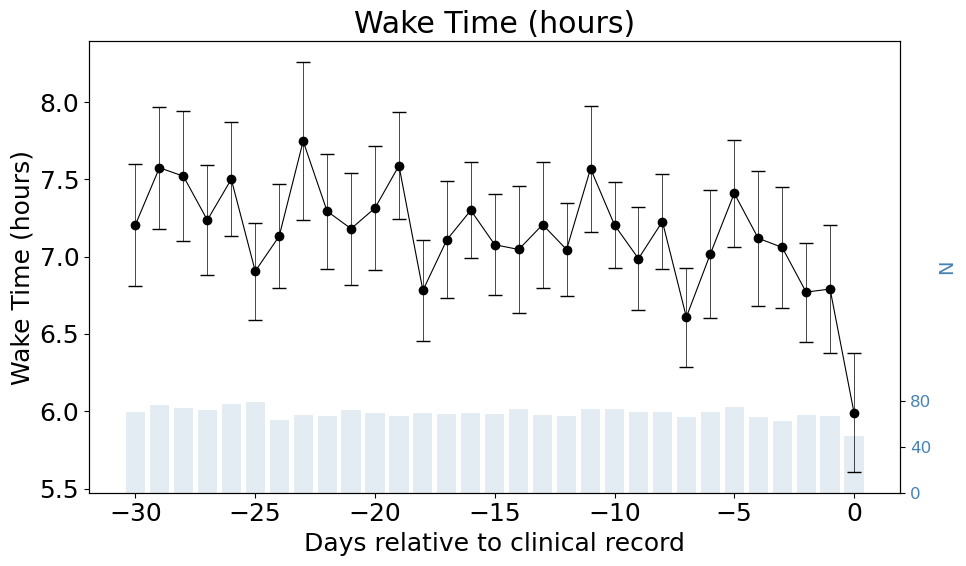

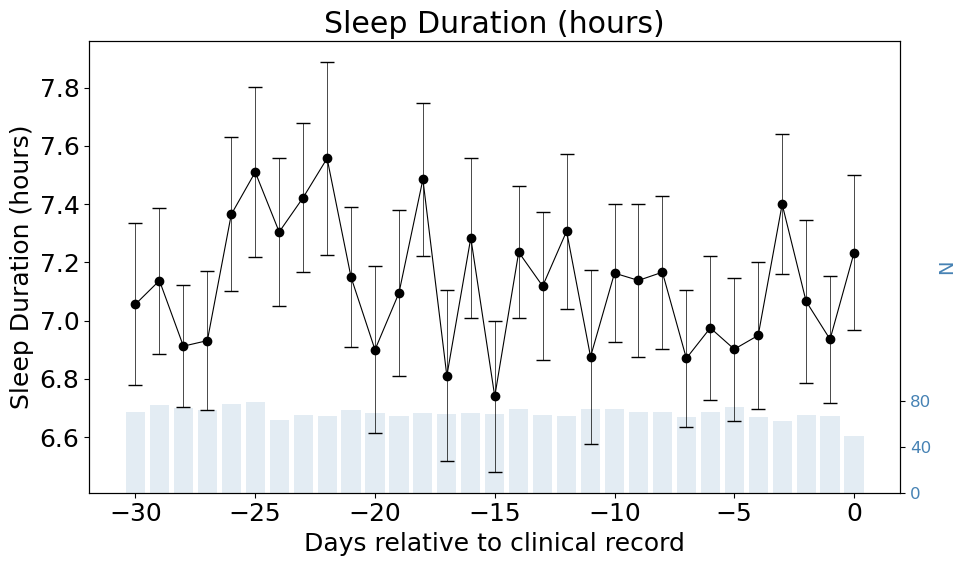

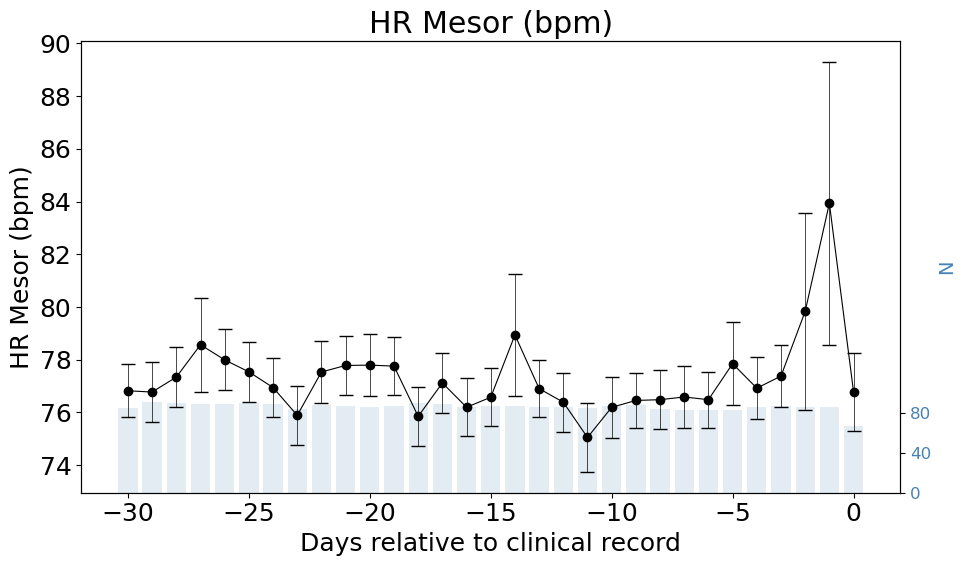

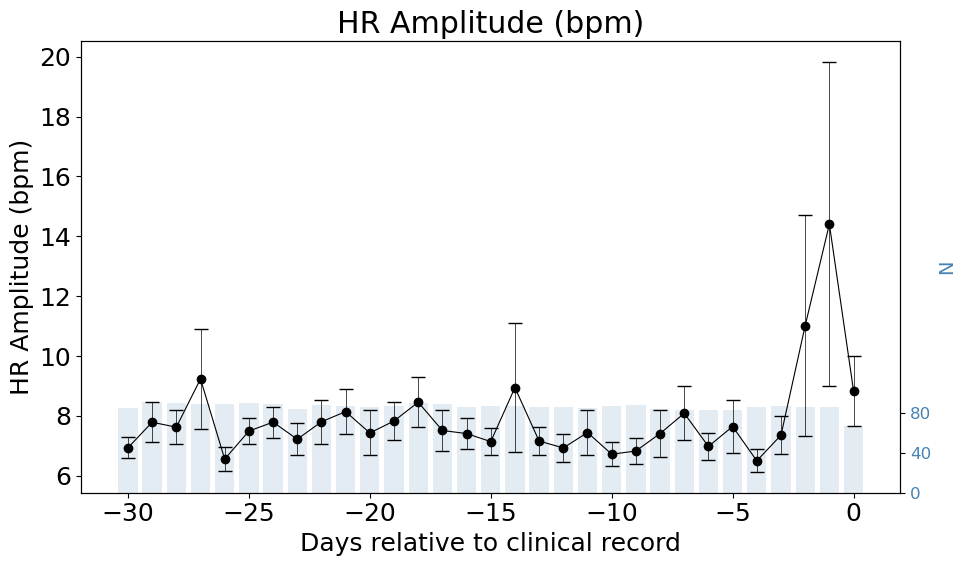

In [8]:
import matplotlib.pyplot as plt

def plot_metric_means(combined_df, target_variable, ylabel,
                      day_col='days_rel_onset'):

    plot_source = combined_df[[target_variable, day_col]].dropna().copy()
    plot_source['day_int'] = plot_source[day_col].astype(int)
    plot_df = (
        plot_source.groupby('day_int')[target_variable]
        .agg(mean='mean', se=lambda x: x.std() / np.sqrt(len(x)), n='count')
        .reset_index()
    )
    plot_df['x_plot'] = plot_df['day_int']
    plot_df = plot_df.sort_values('x_plot')

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # N bars on secondary axis, scaled to occupy bottom 25% of plot
    ax2 = ax1.twinx()
    ax2.bar(plot_df['x_plot'], plot_df['n'], color='steelblue', alpha=0.15, width=0.8)
    ax2.set_ylabel('N', fontsize=14, color='steelblue')
    ax2.tick_params(axis='y', labelcolor='steelblue', labelsize=12)
    ax2.set_ylim(0, plot_df['n'].max() * 5)  
    ax2.set_yticks(np.arange(0,100,40))
    
    # Means + SEs on primary axis
    ax1.errorbar(plot_df['x_plot'], plot_df['mean'], yerr=plot_df['se'],
                 fmt='o', capsize=5, color='k', linewidth=0.5, markersize=6, zorder=3)
    ax1.plot(plot_df['x_plot'], plot_df['mean'], color='k', linewidth=0.8, zorder=2)
    ax1.set_xlabel('Days relative to clinical record')
    ax1.set_ylabel(ylabel)
    ax1.set_zorder(ax2.get_zorder() + 1)  # keeps dots on top of bars
    ax1.patch.set_visible(False)          # lets bars show through
    
    ax1.set_title(ylabel)
    plt.rcParams.update({'font.size': 18})
    plt.tight_layout()

    plt.show()

    return
    
plot_metric_means(combined_df, 'waketime_hours', 'Wake Time (hours)')
plot_metric_means(combined_df, 'duration_hours', 'Sleep Duration (hours)')

plot_metric_means(combined_df, 'mean_hr_mesor', 'HR Mesor (bpm)')
plot_metric_means(combined_df, 'mean_hr_amp', 'HR Amplitude (bpm)')

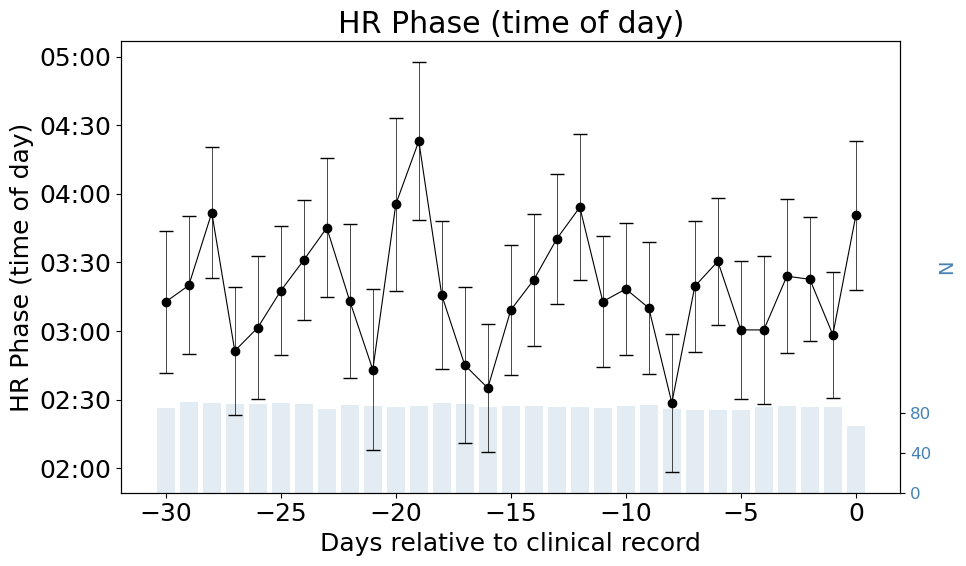

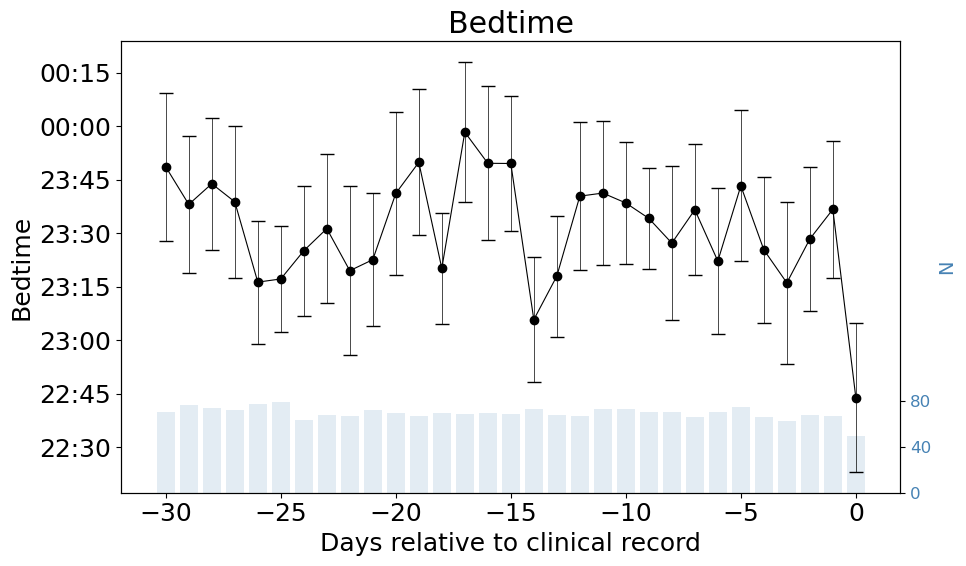

In [9]:
# Circular metric handling

def circular_mean_se(x, period=24):
    angles = 2 * np.pi * x / period
    sin_mean = np.sin(angles).mean()
    cos_mean = np.cos(angles).mean()

    mean_angle = np.arctan2(sin_mean, cos_mean)
    mean_hours = mean_angle * period / (2 * np.pi) % period

    R = np.sqrt(sin_mean**2 + cos_mean**2)
    circ_sd = np.sqrt(-2 * np.log(R)) * period / (2 * np.pi)
    circ_se = circ_sd / np.sqrt(len(x))

    return mean_hours, circ_se


def unwrap_circular_series(vals, period=24):
    vals = np.asarray(vals).copy()

    for i in range(1, len(vals)):
        delta = vals[i] - vals[i - 1]

        if delta > period / 2:
            vals[i:] -= period
        elif delta < -period / 2:
            vals[i:] += period

    return vals


def plot_metric_means_circular(combined_df, target_variable, ylabel,
                                day_col='days_rel_onset', period=24):

    plot_source = combined_df[[target_variable, day_col]].dropna().copy()
    plot_source['day_int'] = plot_source[day_col].astype(int)

    records = []
    for day, group in plot_source.groupby('day_int'):
        m, se = circular_mean_se(group[target_variable], period=period)
        records.append({'day_int': day, 'mean': m, 'se': se, 'n': len(group)})

    plot_df = pd.DataFrame(records)
    plot_df['x_plot'] = plot_df['day_int']
    plot_df = plot_df.sort_values('x_plot')

    plot_df['mean_unwrapped'] = unwrap_circular_series(plot_df['mean'], period=period)

    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax2 = ax1.twinx()
    ax2.bar(plot_df['x_plot'], plot_df['n'],
            color='steelblue', alpha=0.15, width=0.8)

    ax2.set_ylabel('N', fontsize=14, color='steelblue')
    ax2.tick_params(axis='y', labelcolor='steelblue', labelsize=12)
    ax2.set_ylim(0, plot_df['n'].max() * 5)
    ax2.set_yticks(np.arange(0, 100, 40))

    ax1.errorbar(plot_df['x_plot'],
                 plot_df['mean_unwrapped'],
                 yerr=plot_df['se'],
                 fmt='o',
                 capsize=5,
                 color='k',
                 linewidth=0.5,
                 markersize=6,
                 zorder=3)

    ax1.plot(plot_df['x_plot'],
             plot_df['mean_unwrapped'],
             color='k',
             linewidth=0.8,
             zorder=2)

    def hours_to_time(x, _):
        x = x % 24
        h = int(x)
        m = int((x % 1) * 60)
        return f"{h:02d}:{m:02d}"

    ax1.yaxis.set_major_formatter(plt.FuncFormatter(hours_to_time))

    ax1.set_xlabel('Days relative to clinical record')
    ax1.set_ylabel(ylabel)
    ax1.set_zorder(ax2.get_zorder() + 1)
    ax1.patch.set_visible(False)

    ax1.set_title(ylabel)

    plt.rcParams.update({'font.size': 18})
    plt.tight_layout()
    plt.savefig(f"{target_variable}.png")

    plt.show()

    return

plot_metric_means_circular(combined_df, 'mean_hr_phase_hours', 'HR Phase (time of day)')
plot_metric_means_circular(combined_df, 'bedtime_hours', 'Bedtime')